# **Part 1: Convolutions**

- **Parameter-sharing:** The same small filter (kernel) slides across the entire input.
- **Sparse connectivity:** Output pixel only depends on a small local region of the input.

- The **learnable parameters** in a convolutional layer are the weights inside the kernel (filter), plus optional bias terms.

### **Convolve 1 Dimension**

In [1]:
import numpy as np
def conv1d(x, w, p=0, s=1):
    w_rot = np.array(w[::-1])
    x_padded = np.array(x)
    if p > 0:
        zeros_pad = np.zeros(shape=p)
        x_padded = np.concatenate([zeros_pad, x_padded, zeros_pad])
    
    res = []
    for i in range(0, len(x), s):
        res.append(np.sum(x_padded[i:i+w_rot.shape[0]] * w_rot))
    return np.array(res)

In [2]:
## testings:
x = [1, 3, 2, 4, 5, 6, 1, 3]
w = [1, 0, 3, 1, 2]


In [3]:
conv1d(x, w, p=2, s=1)

array([ 5., 14., 16., 26., 24., 34., 19., 22.])

In [4]:
np.convolve(x, w, mode='same')

array([ 5, 14, 16, 26, 24, 34, 19, 22])

### **Convolve 2 Dimensions**

In [5]:
X = [[1, 3, 2, 4], [5, 6, 1, 3], [1, 2, 0, 2], [3, 4, 3, 2]]
W = [[1, 0, 3], [1, 2, 1], [0, 1, 1]]
p = (0, 0)
s = (1,1)

`From Scratch`

In [6]:
def conv2d(X, W, p=(0,0), s=(1,1)):
    # convert to array
    W_rot = np.array(W)[::-1, ::-1]
    X_orig = np.array(X)

    # new dimension size after add the padding
    n1 = X_orig.shape[0] + 2 * p[0]
    n2 = X_orig.shape[1] + 2 * p[1]

    # create a matrix with 0s
    X_padded = np.zeros(shape=(n1, n2))

    # assign the original values to the new matrix
    X_padded[p[0]:p[0] + X_orig.shape[0],
            p[1]:p[1] + X_orig.shape[1]] = X_orig

    # initialize the result
    res = []
    # loop over row and columns
    for i in range(0, int((X_padded.shape[0] - \
                                W_rot.shape[0]))+1, s[0]):
        res.append([])
        for j in range(0, int((X_padded.shape[1] - \
                            W_rot.shape[1]))+1, s[1]):
            X_sub = X_padded[i:i+W_rot.shape[0],
                            j:j+W_rot.shape[1]] # pull the X
            res[-1].append(np.sum(X_sub * W_rot)) # calculate the dot 
    return np.array(res)

In [7]:
conv2d(X, W, p=(1,1), s=(1,1))

array([[11., 25., 32., 13.],
       [19., 25., 24., 13.],
       [13., 28., 25., 17.],
       [11., 17., 14.,  9.]])

`Scipy`

In [8]:
import scipy 
scipy.signal.convolve2d(X, W, mode='same')

array([[11, 25, 32, 13],
       [19, 25, 24, 13],
       [13, 28, 25, 17],
       [11, 17, 14,  9]])

# **Part 2: Subsampling layers**

- Pooling (max-pooling) introduces a local invariance. This means that small changes in a local neighborhood do no chnage the result of max-pooling. Therefor, it helps with generating features that are more robutst to noise in the input data.
- Pooling decreases the size of features, which results in higher computational efficiency.

In [9]:
import numpy as np

# Define the four 3x3 matrices from the image
matrix1 = np.array([
    [2, 1, 7],
    [5, 0, 3],
    [1, 7, 8]
])

matrix2 = np.array([
    [1, 2, 5],
    [4, 1, 2],
    [3, 3, 0]
])

matrix3 = np.array([
    [0, 3, 2],
    [6, 2, 5],
    [3, 6, 0]
])

matrix4 = np.array([
    [0, 1, 1],
    [3, 0, 3],
    [2, 1, 0]
])

# Combine into a single 4x3x3 numpy array (batch of 4 matrices)
combined_array = np.array([matrix1, matrix2, matrix3, matrix4])

print("Combined 4x3x3 NumPy Array:")
print(combined_array)


Combined 4x3x3 NumPy Array:
[[[2 1 7]
  [5 0 3]
  [1 7 8]]

 [[1 2 5]
  [4 1 2]
  [3 3 0]]

 [[0 3 2]
  [6 2 5]
  [3 6 0]]

 [[0 1 1]
  [3 0 3]
  [2 1 0]]]


In [10]:
matrix1.mean()

3.7777777777777777

In [11]:
matrix2.mean()

2.3333333333333335

In [12]:
matrix3.mean()

3.0

In [13]:
matrix4.mean()

1.2222222222222223

## **Part 3: Learnable Parameters**

In [14]:
import tensorflow as tf
import numpy as np

# Create a sample input image (batch of 1, 32x32 RGB image)
input_image = np.random.rand(1, 32, 32, 3).astype(np.float32)

# Define a convolutional layer with 64 filters
conv_layer = tf.keras.layers.Conv2D(
    filters=64,           # 64 feature maps
    kernel_size=(3, 3),   # 3x3 filter size
    strides=1,
    padding='same',
    activation='relu'
)

# Apply the convolutional layer
output = conv_layer(input_image)

print("Input shape:", input_image.shape)   # (1, 32, 32, 3)
print("Output shape:", output.shape)       # (1, 32, 32, 64)

# The output has 64 feature maps — one for each filter
print("\nNumber of feature maps:", output.shape[-1])  # 64

# You can access individual feature maps:
print("\nFirst feature map shape:", output[0, :, :, 0].shape)  # (32, 32)
print("Second feature map shape:", output[0, :, :, 1].shape)   # (32, 32)


Input shape: (1, 32, 32, 3)
Output shape: (1, 32, 32, 64)

Number of feature maps: 64

First feature map shape: (32, 32)
Second feature map shape: (32, 32)


- **Leanrable Parameters**
    - (m1 x m2 x input_channels) x num_filters + num_filters
    - m1: height of the kernel (filter)
    - m2: width of the kernel (filter)
    - input_channels: the colors

## Part 4: Regularizing

`L2 regularization`

In [15]:
from tensorflow import keras
conv_layer = keras.layers.Conv2D(
    filters=16,
    kernel_size=(3,3),
    kernel_regularizer=keras.regularizers.l2(l2=0.001) # it controls how much we penalize large weights in the kernel
)

`Dropout()`
- Droput is usually applied to the hidden units of hidden layers and works as follows: during the training phase of an NN, a fraction of the hidden units randomly dropped at every iteration with probability `P`. This dropout probability is determined by the user and the common choice is `p=0.5`.
- but during the evaluation phase, all the hidden units must be active.

## Part 5: Loss function for classification
- **BinaryCrossentropy**: binary calssificaiton
- **CategoricalCrossentropy**: multicalss with one-hot encoded ground truth labels
- **SparseCategoricalCrossentropy**: multicalss with integer (sparse) labels.

In [16]:
import tensorflow as tf
import tensorflow_datasets as tfds

bce_probas = tf.keras.losses.BinaryCrossentropy(from_logits=False) # expects probabilities (values between 0 and 1, typically after applyinga sigmoid activation)
bce_logits = tf.keras.losses.BinaryCrossentropy(from_logits=True) # expects logits (raw, unnormalized scores, before applying sigmoid)
y_true = tf.constant([1.0])

logits = tf.constant([0.8])
probas = tf.keras.activations.sigmoid(logits)

In [17]:
tf.print(
     'BCE (w Probas): {:.4f}'.format(
     bce_probas(y_true=y_true, y_pred=probas)),
     '(w Logits): {:.4f}'.format(
     bce_logits(y_true=y_true, y_pred=logits)))

BCE (w Probas): 0.3711 (w Logits): 0.3711


## **Part 5: Implementing a deep CNN using TensorFlow - MNIST**

#### Step 1: Load Data

In [18]:
import tensorflow_datasets as tfds
dataset = tfds.load('mnist', split=['train','test'], shuffle_files=False)

mnist_train_orig = dataset[0]
mnist_test_orig = dataset[0]


#### Step 2: Prepare the data

In [19]:
BUFFER_SIZE=10000
BATCH_SIZE=64
NUM_EPOCHS=20

mnist_train = mnist_train_orig.map(
    lambda item: (tf.cast(item['image'], tf.float32) / 255.0,
                  tf.cast(item['label'], tf.int32))
)

mnist_test = mnist_test_orig.map(
    lambda item: (tf.cast(item['image'], tf.float32) / 255.0,
                  tf.cast(item['label'], tf.int32))
)

tf.random.set_seed(1)
mnist_train = mnist_train.shuffle(buffer_size=BUFFER_SIZE,
                                  reshuffle_each_iteration=False)
mnist_valid = mnist_train.take(10000).batch(BATCH_SIZE)
mnist_train = mnist_train.skip(1000).batch(BATCH_SIZE)
mnist_test = mnist_test.batch(BATCH_SIZE)

#### Step 3: Constructing a CNN in Keras

In [20]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(
    filters=32, kernel_size=(5,5),
    strides=(1,1), padding='same',
    data_format='channels_last',
    name='conv_1', activation='relu'
))
model.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2,2),  name='pool_1'
))

model.add(tf.keras.layers.Conv2D(
    filters=64, kernel_size=(5,5),
    strides=(1,1), padding='same',
    name='conv_2', activation='relu'
))
model.add(tf.keras.layers.MaxPooling2D(
    pool_size=(2,2), name='pool_2'
))

In [21]:
model.compute_output_shape(input_shape=(16,28,28,1)) # batch = 16; 28 = height, 28 = width, channel = 1
# there are two convolutations, each time with pool_size = (2,2), so reduce size to half each time.
# the second filters = 64, output size would be 64
# this won't change the channel size

(16, 7, 7, 64)

In [22]:
model.add(tf.keras.layers.Flatten()) # dense layer is fully connected, which must have rank 2, that is, shape [batchsize x input_units]
model.compute_output_shape(input_shape=(16,28,28,1))

(16, 3136)

In [23]:
7*7*64

3136

In [24]:
# dense layer
model.add(tf.keras.layers.Dense(units=1024, name='fc_1',
                                activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(units=10, name='fc_2',
                                activation='softmax'))

In [25]:
tf.random.set_seed(1)
model.build(input_shape=(None, 28, 28,1)) # Initializes the model's weights and sets up its architecture based on teh specified input shape, without performing a forward pass
model.compile(
    optimizer=tf.keras.optimizers.Adam(), # AdaGrid(); RMSProp
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), # multiclass classification with integer (sparse) label
    metrics=['accuracy']
)

In [26]:
history = model.fit(mnist_train, epochs=10, validation_data=mnist_test, shuffle=True)

Epoch 1/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9601 - loss: 0.1280 - val_accuracy: 0.9896 - val_loss: 0.0342
Epoch 2/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9863 - loss: 0.0439 - val_accuracy: 0.9917 - val_loss: 0.0259
Epoch 3/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9911 - loss: 0.0290 - val_accuracy: 0.9952 - val_loss: 0.0162
Epoch 4/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9956 - val_loss: 0.0139
Epoch 5/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9959 - val_loss: 0.0122
Epoch 6/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9953 - loss: 0.0151 - val_accuracy: 0.9969 - val_loss: 0.0095
Epoch 7/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9958 - loss: 0.0132 - val_accuracy: 0.9971 - val_loss: 0.0088
Epoch 8/10
922/922 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9958 - loss: 0.0127 - 

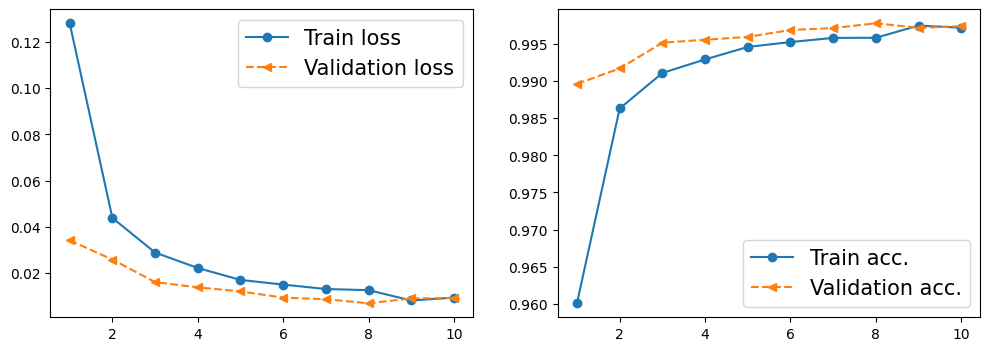

In [27]:
import matplotlib.pyplot as plt
hist = history.history

x_arr = np.arange(len(hist['loss'])) + 1
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)

ax = fig.add_subplot(1,2,2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
plt.show()

In [ ]:
# Evaluate on test data
test_results = model.evaluate(mnist_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9974 - loss: 0.0093


In [38]:
# prediction 
batch_test = next(iter(mnist_test)) # create an iterator over the dataset andt extract first element
preds = model(batch_test[0]) # batch_test[0] pulls the test data (doesn't include the label). # Passes the batched input through the model to get predictions.
tf.print(preds.shape)

TensorShape([64, 10])


In [39]:
preds = tf.argmax(preds, axis=1)

In [41]:
print(preds[:12])

tf.Tensor([4 1 0 7 8 1 2 7 1 6 6 4], shape=(12,), dtype=int64)


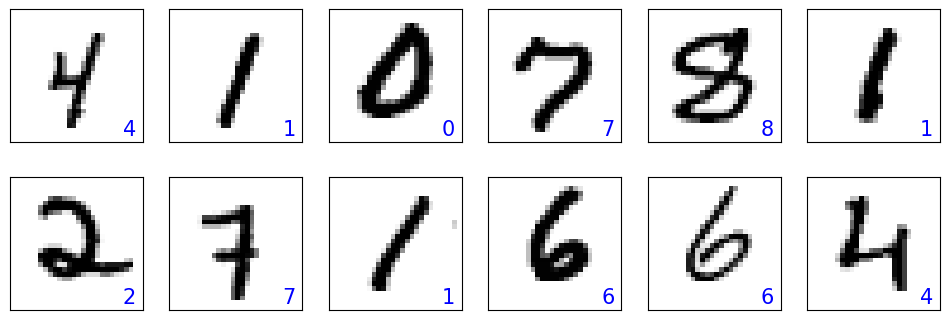

In [44]:
fig = plt.figure(figsize=(12,4))
for i in range(12):
    ax = fig.add_subplot(2,6,i+1)
    ax.set_xticks([])
    ax.set_yticks([])

    img = batch_test[0][i, :, :, 0]
    ax.imshow(img, cmap='gray_r')
    ax.text(0.9, 0.1, '{}'.format(preds[i]),
            size=15, color='blue',
            horizontalalignment = 'center',
            verticalalignment='center',
            transform=ax.transAxes)
plt.show()

## **Part 6 - Gender classification from face images using a CNN**

#### Step 1 - Loading the CelebA dataset

In [1]:
import tensorflow_datasets as tfds

In [3]:
celeba = tfds.load('celeb_a', shuffle_files=False, split=['train','validation','test'])

In [5]:
celeba_train = celeba[0]
celeba_valid = celeba[1]
celeba_test = celeba[2]

In [7]:
def count_items(ds):
    n = 0
    for i in ds:
        n+=1
    return n

In [8]:
print(f'Train set: {count_items(celeba_train)}')

Train set: 162770


2026-07-05 23:16:39.188446: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
print(f'Validation set: {count_items(celeba_valid)}')

Validation set: 19867


2026-07-05 23:16:41.980058: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
print(f'Test set: {count_items(celeba_test)}')

Test set: 19962


2026-07-05 23:16:51.057673: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
# only use 16,000 training examples adn 1,000 examples for validation
celeba_train = celeba_train.take(16000)
celeba_valid = celeba_valid.take(1000)

In [12]:
print(f'Train set: {count_items(celeba_train)}')

Train set: 16000


2026-07-05 23:18:29.507586: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
print(f'Validation set: {count_items(celeba_valid)}')

Validation set: 1000


2026-07-05 23:18:37.057739: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Step 2: Image transformation and data augmentation

2026-07-06 11:40:20.631351: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


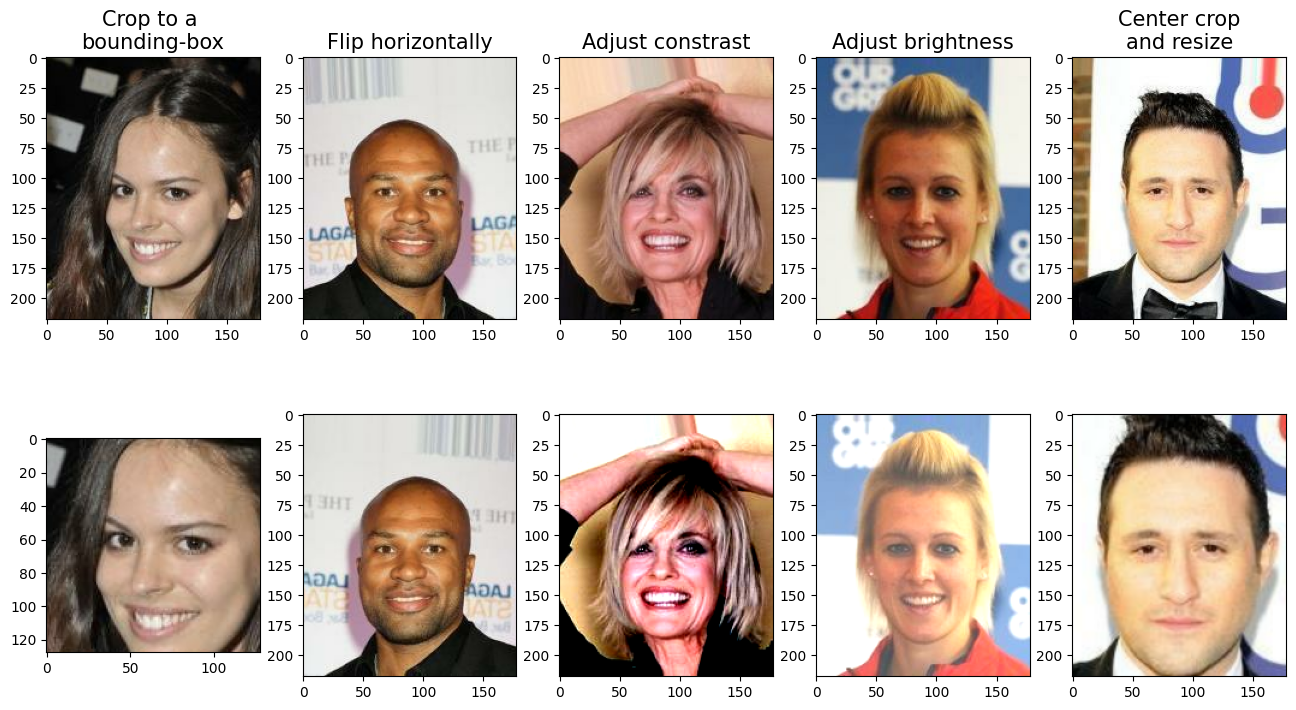

In [16]:
import matplotlib.pyplot as plt
import tensorflow as tf

examples = []
for example in celeba_train.take(5):
    examples.append(example['image'])
fig = plt.figure(figsize=(16,8.5))

## Column 1: cropping to a bounding-box
ax = fig.add_subplot(2,5,1)
ax.set_title('Crop to a \nbounding-box', size=15)
ax.imshow(examples[0])

ax = fig.add_subplot(2,5,6)
img_cropped = tf.image.crop_to_bounding_box(examples[0], 50, 20, 128, 128) # extracts a 128 x 128 pixel region from the image, starting at pixel corrdinates (50, 20)
ax.imshow(img_cropped)


## Column 2: flipping (horizontally)
ax = fig.add_subplot(2,5,2)
ax.set_title('Flip horizontally', size=15)
ax.imshow(examples[1])
ax = fig.add_subplot(2,5,7)
ax.imshow(tf.image.flip_left_right(examples[1]))

## Column 3: adjust contrast
ax = fig.add_subplot(2,5,3)
ax.set_title('Adjust constrast', size=15)
ax.imshow(examples[2])
ax = fig.add_subplot(2,5,8)
img_adj_contrast = tf.image.adjust_contrast(examples[2], contrast_factor=2)
ax.imshow(img_adj_contrast)

## Column 4: adjust brightness
ax = fig.add_subplot(2,5,4)
ax.set_title('Adjust brightness', size=15)
ax.imshow(examples[3])
ax = fig.add_subplot(2,5,9)
img_adj_brightness = tf.image.adjust_brightness(
    examples[3], delta=0.3
)
ax.imshow(img_adj_brightness)

## Column 5: cropping from image center
ax = fig.add_subplot(2,5,5)
ax.set_title('Center crop\nand resize', size=15)
ax.imshow(examples[4])
ax = fig.add_subplot(2,5,10)
img_center_crop = tf.image.central_crop(
    examples[4], 0.7
)
img_resized = tf.image.resize(
    img_center_crop, size=(218, 178)
)
ax.imshow(img_resized.numpy().astype('uint8'))
plt.show()


2026-07-06 11:57:34.905327: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


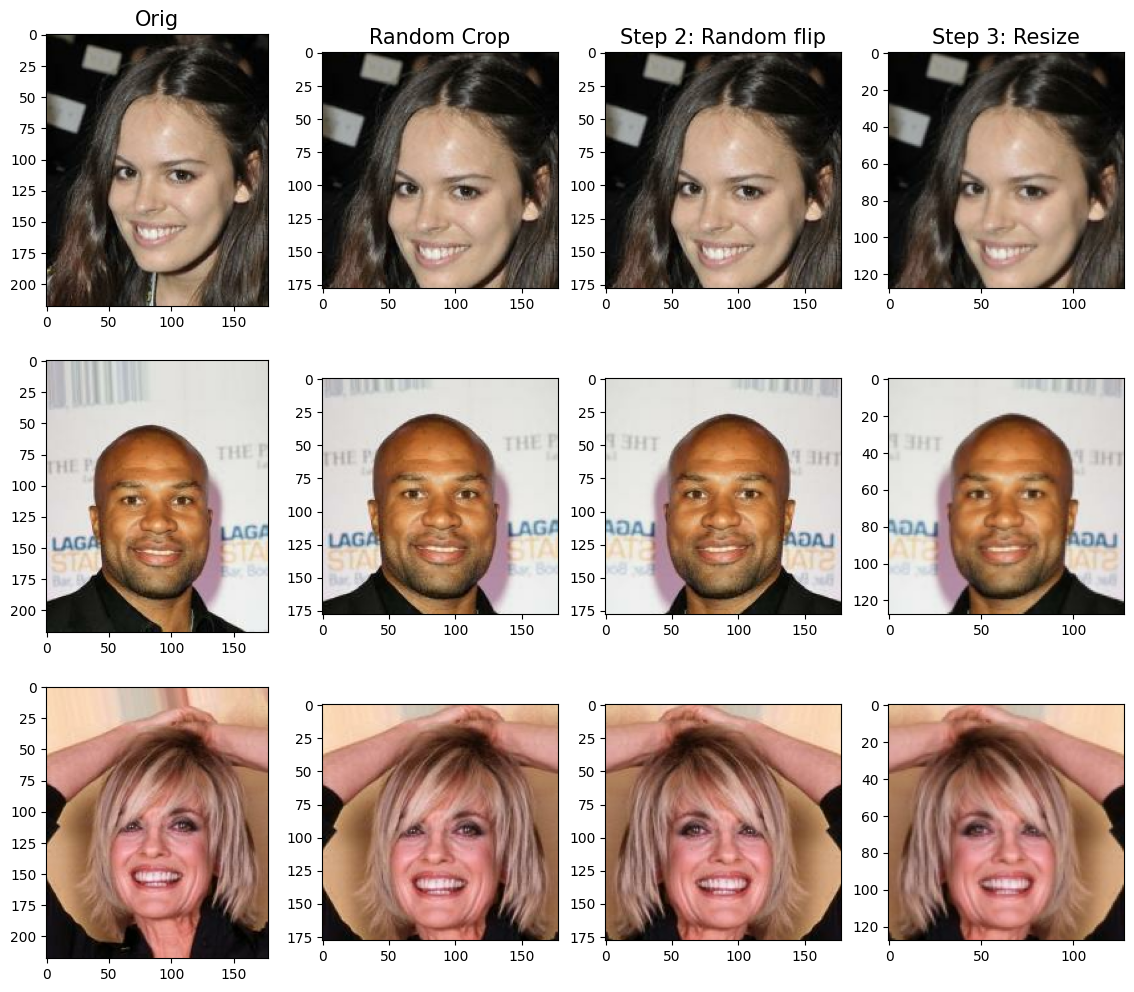

In [19]:
# radnom adjust images
tf.random.set_seed(1)

fig = plt.figure(figsize=(14,12))
for i, example in enumerate(celeba_train.take(3)):
    image = example['image']

    ax = fig.add_subplot(3,4, i*4 + 1)
    ax.imshow(image)
    if i == 0:
        ax.set_title('Orig', size=15)
    ax = fig.add_subplot(3,4, i*4+2)
    img_crop = tf.image.random_crop(image, size=(178,178,3))
    ax.imshow(img_crop)
    if i == 0:
        ax.set_title('Random Crop', size=15)
    
    ax = fig.add_subplot(3,4, i*4+3)
    img_flip = tf.image.random_flip_left_right(img_crop)
    ax.imshow(tf.cast(img_flip, tf.uint8))
    if i == 0:
        ax.set_title('Step 2: Random flip', size=15)

    ax = fig.add_subplot(3,4,i*4+4)
    img_resize = tf.image.resize(img_flip, size=(128,128))
    ax.imshow(tf.cast(img_resize, tf.uint8))
    if i == 0:
        ax.set_title('Step 3: Resize', size=15)
plt.show()

In [20]:
# create a wrapper function
def preprocess(example, size=(64,64), mode='train'):
    image = example['image']
    label = example['attributes']['Male']
    if mode == 'train':
        image_cropped = tf.image.random_crop(
            image, size=(178,178, 3))
        image_resize = tf.image.resize(
            image_cropped, size=size)
        image_flip = tf.image.random_flip_left_right(
            image_resize)
        return image_flip/255.0, tf.cast(label, tf.int32)
    else:
        image_cropped = tf.image.crop_to_bounding_box(image, 20, 0, 178,  178)
        image_resize = tf.image.resize(image_cropped, size=size)
        return image_resize/255.0, tf.cast(label, tf.int32)

2026-07-06 12:05:12.210050: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


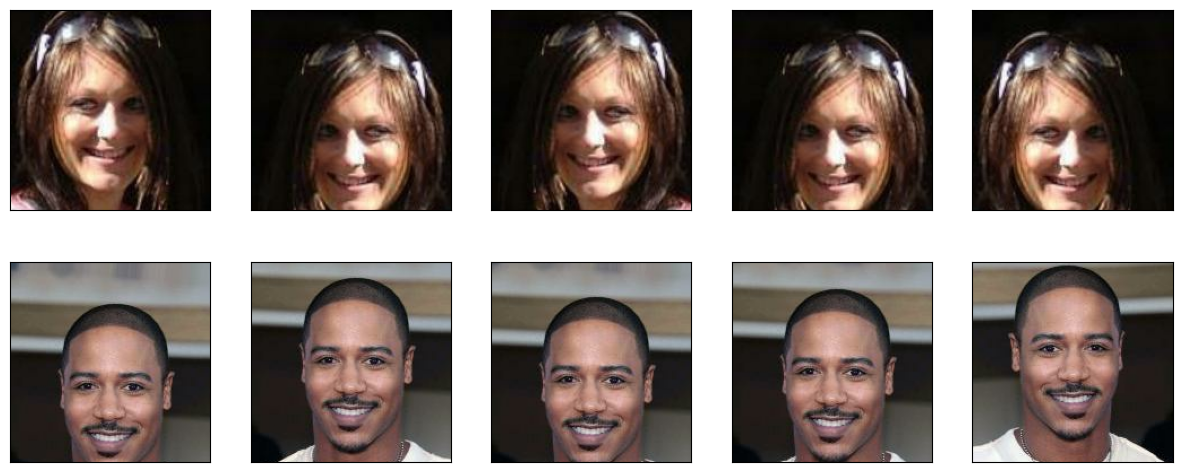

In [23]:
tf.random.set_seed(1)
ds = celeba_train.shuffle(1000, reshuffle_each_iteration=False)
ds = ds.take(2).repeat(5)
ds = ds.map(lambda x:preprocess(x, size=(178, 178), mode='train'))
fig = plt.figure(figsize=(15, 6))
for j,example in enumerate(ds):
     ax = fig.add_subplot(2, 5, j//2+(j%2)*5+1)
     ax.set_xticks([])
     ax.set_yticks([])
     ax.imshow(example[0])
plt.show()

In [24]:
import numpy as np
BATCH_SIZE = 32
BUFFER_SIZE = 1000
IMAGE_SIZE = (64, 64)
steps_per_epoch = np.ceil(16000/BATCH_SIZE)
ds_train = celeba_train.map(
    lambda x: preprocess(x, size=IMAGE_SIZE, mode='train'))
ds_train = ds_train.shuffle(buffer_size=BUFFER_SIZE).repeat()
ds_train = ds_train.batch(BATCH_SIZE)
ds_valid = celeba_valid.map(
   lambda x: preprocess(x, size=IMAGE_SIZE, mode='eval'))
ds_valid = ds_valid.batch(BATCH_SIZE)

#### Step 3: Training a CNN gender classifier

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(rate=0.5),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(rate=0.5),

    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(rate=0.5),

    tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu')

])

In [29]:
model.compute_output_shape(input_shape=(None, 64,64,3))

(None, 8, 8, 256)

In [30]:
model.add(tf.keras.layers.GlobalAveragePooling2D())

In [31]:
model.compute_output_shape(input_shape=(None, 64,64,3))

(None, 256)

In [34]:
# add a fully connected layers
model.add(tf.keras.layers.Dense(1, activation=None))
tf.random.set_seed(1)
model.build(input_shape=(None, 64,64,3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,675 (1.48 MB)

 Trainable params: 388,675 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy'])

history = model.fit(ds_train, validation_data=ds_valid,
                    epochs=20,
                    steps_per_epoch = int(steps_per_epoch) # specific the number of batches (or steps) to process from the training dataset before considering one epoch complete.
                    )

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.5830 - loss: 0.6707 - val_accuracy: 0.5780 - val_loss: 0.6294
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6606 - loss: 0.5859 - val_accuracy: 0.7320 - val_loss: 0.5174
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7113 - loss: 0.5287 - val_accuracy: 0.7590 - val_loss: 0.4580
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7520 - loss: 0.4837 - val_accuracy: 0.7930 - val_loss: 0.4155
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7743 - loss: 0.4501 - val_accuracy: 0.8240 - val_loss: 0.3881
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7931 - loss: 0.4153 - val_accuracy: 0.8400 - val_loss: 0.3318
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.8292 - loss: 0.3593 - val_accuracy: 0.8370 - val_loss: 0.2978
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8507 - loss: 0.3222 - 

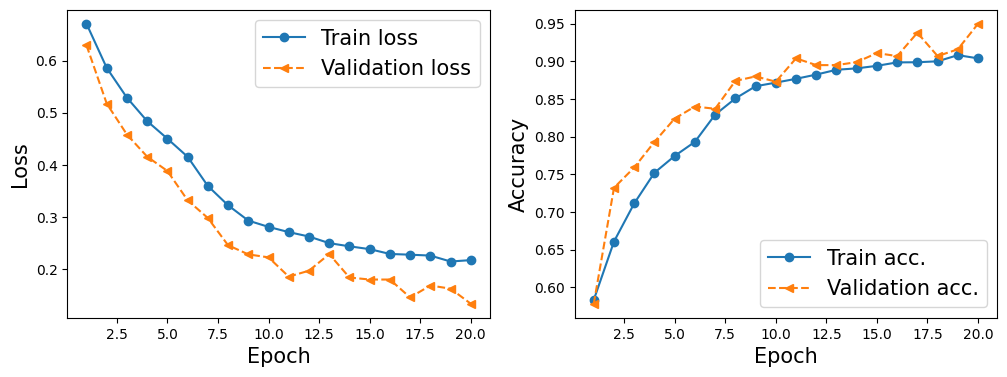

In [37]:
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<',
        label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
plt.show()

In [ ]:
history = model.fit(ds_train, validation_data=ds_valid,
                    epochs=30, initial_epoch=20, # initial_epoch=20, train the model start from 20th epoch
                    steps_per_epoch=int(steps_per_epoch))

Epoch 21/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9073 - loss: 0.2125 - val_accuracy: 0.8800 - val_loss: 0.1978
Epoch 22/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9082 - loss: 0.2048 - val_accuracy: 0.9290 - val_loss: 0.1504
Epoch 23/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9092 - loss: 0.2057 - val_accuracy: 0.9360 - val_loss: 0.1334
Epoch 24/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9101 - loss: 0.2007 - val_accuracy: 0.9330 - val_loss: 0.1457
Epoch 25/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.9109 - loss: 0.2034 - val_accuracy: 0.9410 - val_loss: 0.1270
Epoch 26/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9144 - loss: 0.2016 - val_accuracy: 0.9120 - val_loss: 0.1601
Epoch 27/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9192 - loss: 0.1896 - val_accuracy: 0.8950 - val_loss: 0.1865
Epoch 28/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9140 - loss: 0

In [43]:
# evaluate the data on the test data
ds_test = celeba_test.map(
    lambda x: preprocess(x, size = IMAGE_SIZE, mode='evla')).batch(32)
test_results = model.evaluate(ds_test)
print('Test acc: {:.2f}%'.format(test_results[1]*100))

624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9293 - loss: 0.1460
Test acc: 92.93%


#### Step 4: prediction

In [46]:
ds = ds_test.unbatch().take(10)
pred_logits = model.predict(ds.batch(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


/opt/anaconda3/envs/tf_m1/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-07-06 15:02:51.505767: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [47]:
pred_logits

array([[-13.042032  ],
       [ -0.7052102 ],
       [ -1.2111641 ],
       [  1.3239226 ],
       [-10.897878  ],
       [  4.0089273 ],
       [  1.1591415 ],
       [ -0.86505127],
       [  4.6204653 ],
       [  7.4101768 ]], dtype=float32)

In [48]:
probas = tf.sigmoid(pred_logits)
probas

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[2.1672872e-06],
       [3.3065808e-01],
       [2.2949514e-01],
       [7.8983361e-01],
       [1.8497109e-05],
       [9.8217082e-01],
       [7.6117676e-01],
       [2.9628506e-01],
       [9.9024785e-01],
       [9.9939531e-01]], dtype=float32)>

In [49]:
probas = probas.numpy().flatten()*100
probas

array([2.1672872e-04, 3.3065807e+01, 2.2949514e+01, 7.8983360e+01,
       1.8497108e-03, 9.8217079e+01, 7.6117676e+01, 2.9628506e+01,
       9.9024788e+01, 9.9939529e+01], dtype=float32)

2026-07-06 15:06:56.065914: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


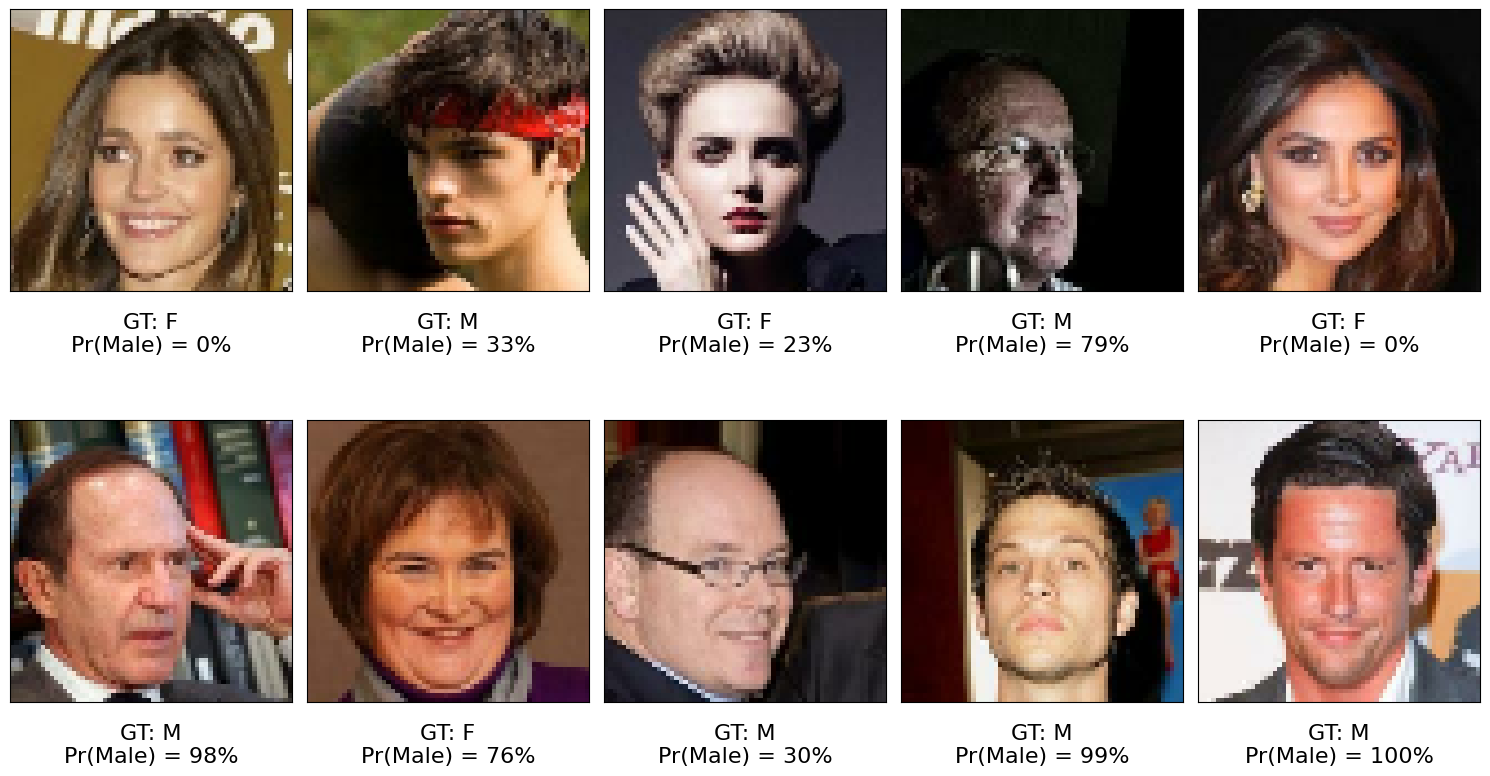

In [51]:
fig = plt.figure(figsize=(15,9))
for j, example in enumerate(ds):
    ax = fig.add_subplot(2,5, j+1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(example[0])
    if example[1].numpy() == 1:
        label='M'
    else:
        label='F'
    ax.text(
        0.5, -0.15, 'GT: {:s}\nPr(Male) = {:.0f}%'.format(label, probas[j]),
        size = 16,
        horizontalalignment = 'center',
        verticalalignment = 'center',
        transform=ax.transAxes
    )
plt.tight_layout()
plt.show()